In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 110

# Ganti path sesuai lokasi file di Colab (misal setelah upload / mount drive)
df = pd.read_csv('clean_dataset.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])

print(df.shape)
df.head()

(48105, 4)


,tanggal,nama_produk,qty,product_id
0,2022-01-01,aglonema_rotundum_aceh,0.0,1
1,2022-01-02,aglonema_rotundum_aceh,0.0,1
2,2022-01-03,aglonema_rotundum_aceh,0.0,1
3,2022-01-04,aglonema_rotundum_aceh,0.0,1
4,2022-01-05,aglonema_rotundum_aceh,0.0,1


## Grafik 1 — Tren Total Penjualan Harian (dengan Rolling Average)

Menunjukkan pola keseluruhan dari waktu ke waktu. Ini penting sebelum masuk ke model karena kita bisa lihat tren & musiman secara kasar.

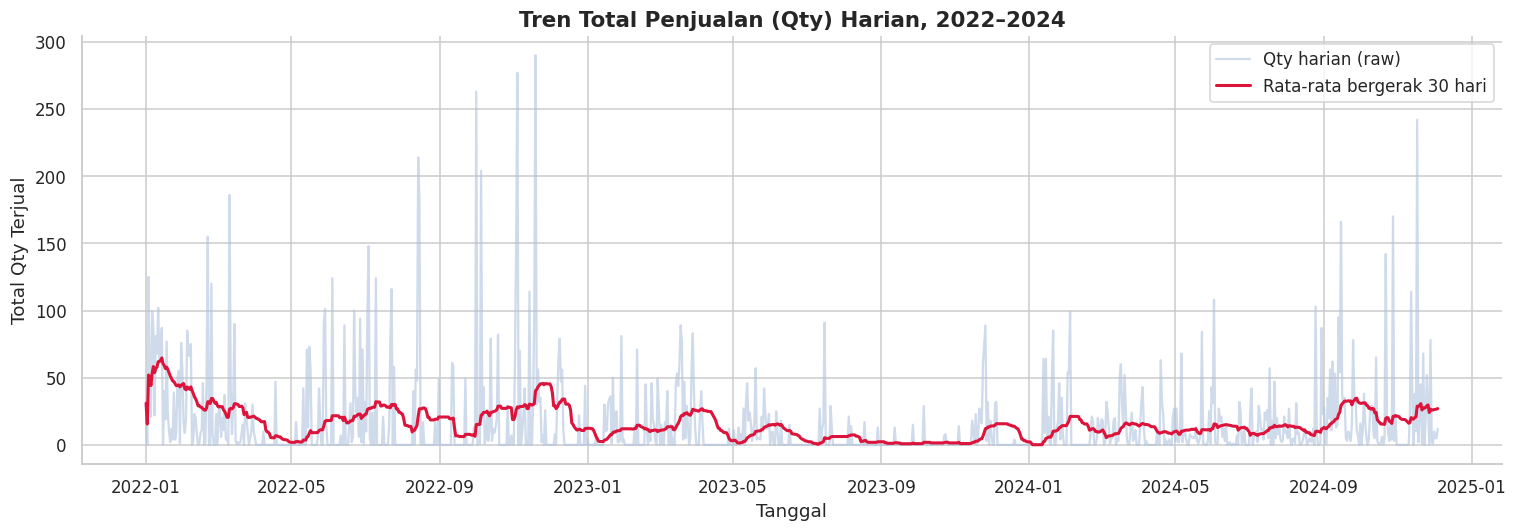

In [2]:
daily = df.groupby('tanggal')['qty'].sum().reset_index()
daily['rolling_30'] = daily['qty'].rolling(30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['tanggal'], daily['qty'], color='lightsteelblue', alpha=0.6, label='Qty harian (raw)')
ax.plot(daily['tanggal'], daily['rolling_30'], color='crimson', linewidth=2, label='Rata-rata bergerak 30 hari')

ax.set_title('Tren Total Penjualan (Qty) Harian, 2022–2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Total Qty Terjual')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Grafik 2 — Top 10 Produk Terlaris

/tmp/ipykernel_2272/95516203.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='mako', ax=ax)


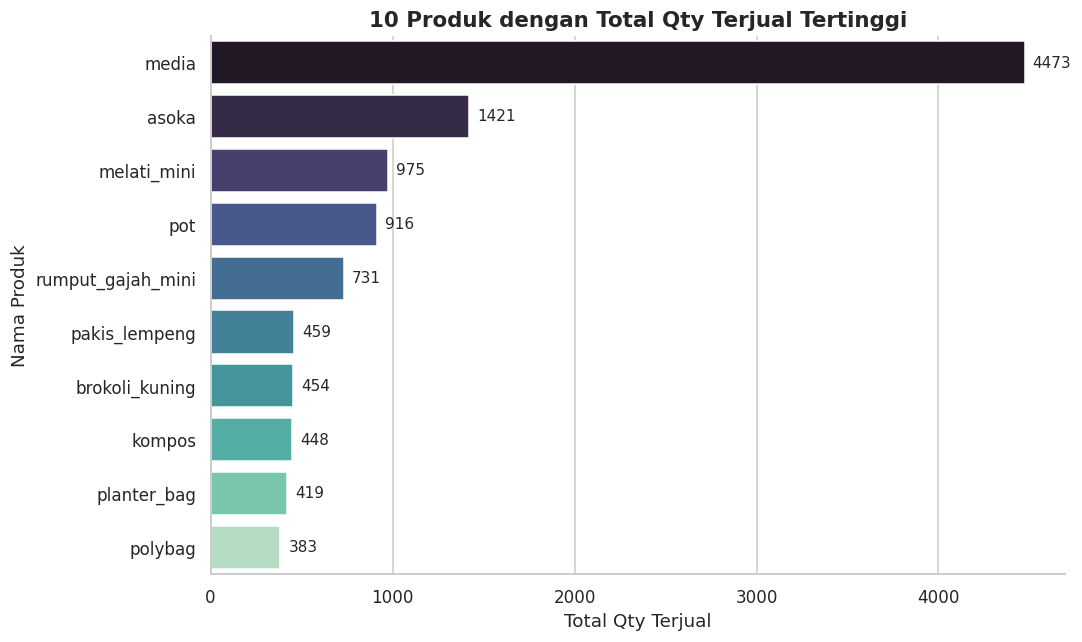

In [3]:
top10 = df.groupby('nama_produk')['qty'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, palette='mako', ax=ax)

for i, v in enumerate(top10.values):
    ax.text(v + max(top10.values)*0.01, i, f'{int(v)}', va='center', fontsize=10)

ax.set_title('10 Produk dengan Total Qty Terjual Tertinggi', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Qty Terjual')
ax.set_ylabel('Nama Produk')
sns.despine()
plt.tight_layout()
plt.show()

## Grafik 3 — Heatmap Pola Musiman (Bulan × Tahun)

Sangat berguna untuk melihat musim ramai/sepi penjualan.

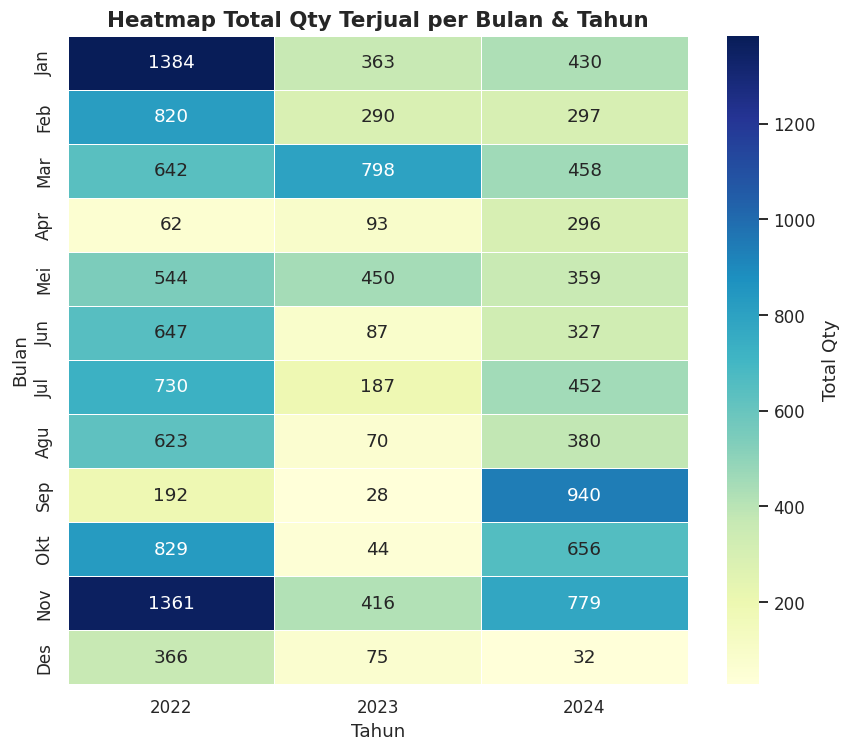

In [4]:
df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month

pivot = df.pivot_table(index='bulan', columns='tahun', values='qty', aggfunc='sum')
bulan_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5,
            yticklabels=bulan_label, cbar_kws={'label': 'Total Qty'}, ax=ax)

ax.set_title('Heatmap Total Qty Terjual per Bulan & Tahun', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('Bulan')
plt.tight_layout()
plt.show()

## Grafik 4 — Distribusi Qty & Proporsi Hari Tanpa Penjualan / Data Tidak Ada

Menunjukkan data sparsity.

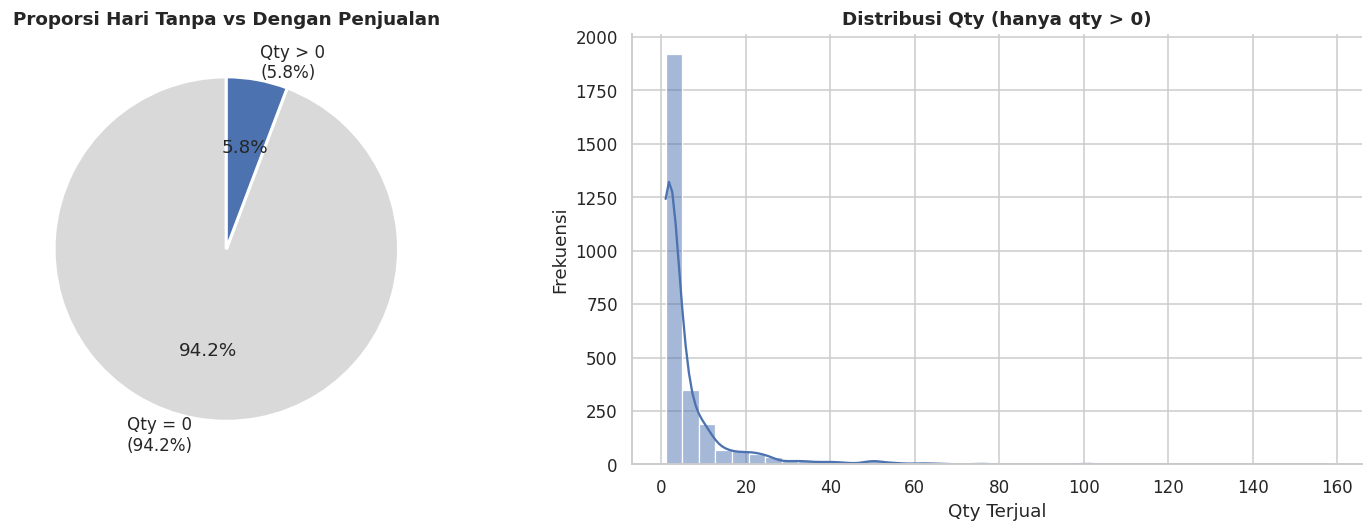

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart proporsi nol vs tidak nol
zero_ratio = (df['qty'] == 0).mean()
sizes = [zero_ratio, 1 - zero_ratio]
labels = [f'Qty = 0\n({zero_ratio:.1%})', f'Qty > 0\n({1-zero_ratio:.1%})']
colors = ['#d9d9d9', '#4c72b0']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporsi Hari Tanpa vs Dengan Penjualan', fontsize=12, fontweight='bold')

# Histogram qty > 0 saja (biar distribusinya kebaca, karena didominasi nol)
nonzero = df[df['qty'] > 0]['qty']
sns.histplot(nonzero, bins=40, kde=True, color='#4c72b0', ax=axes[1])
axes[1].set_title('Distribusi Qty (hanya qty > 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Qty Terjual')
axes[1].set_ylabel('Frekuensi')

sns.despine()
plt.tight_layout()
plt.show()

## Grafik 5 — Pola Penjualan Berdasarkan Hari dalam Seminggu

/tmp/ipykernel_2272/1707739843.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_hari.index, y=avg_hari.values, palette='rocket', ax=ax)


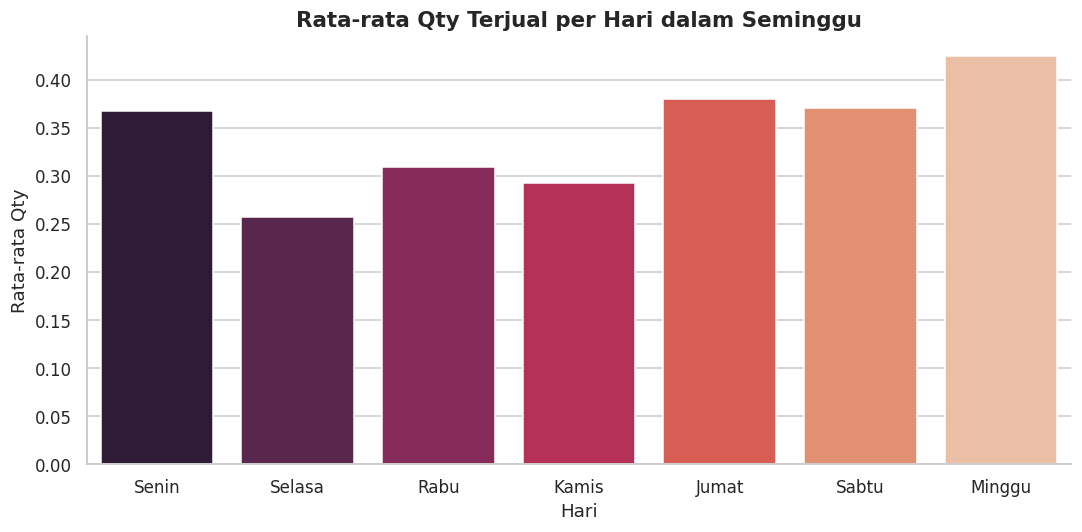

In [6]:
df['hari'] = df['tanggal'].dt.day_name()
urutan_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
label_id = {'Monday':'Senin','Tuesday':'Selasa','Wednesday':'Rabu','Thursday':'Kamis',
            'Friday':'Jumat','Saturday':'Sabtu','Sunday':'Minggu'}

avg_hari = df.groupby('hari')['qty'].mean().reindex(urutan_hari)
avg_hari.index = [label_id[h] for h in avg_hari.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=avg_hari.index, y=avg_hari.values, palette='rocket', ax=ax)

ax.set_title('Rata-rata Qty Terjual per Hari dalam Seminggu', fontsize=14, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Rata-rata Qty')
sns.despine()
plt.tight_layout()
plt.show()

## Grafik 6 — Tren Produk Terlaris

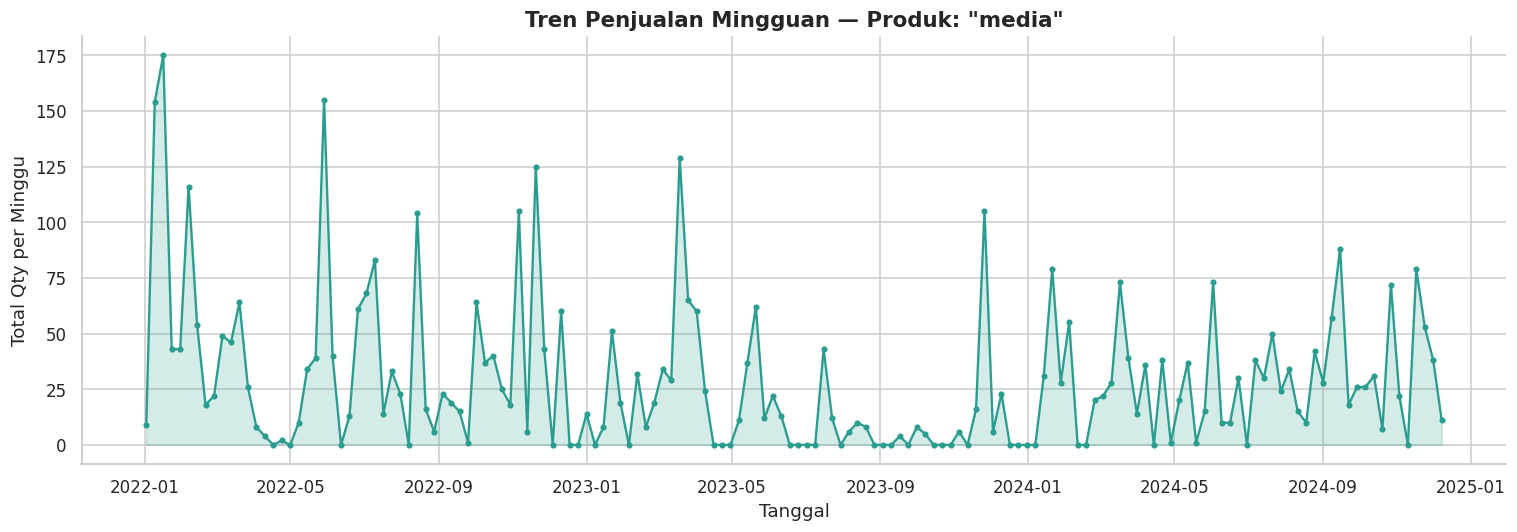

In [7]:
produk_top1 = df.groupby('nama_produk')['qty'].sum().idxmax()
df_produk = df[df['nama_produk'] == produk_top1].set_index('tanggal')['qty']

weekly = df_produk.resample('W').sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly.index, weekly.values, marker='o', markersize=3, color='#2a9d8f')
ax.fill_between(weekly.index, weekly.values, alpha=0.2, color='#2a9d8f')

ax.set_title(f'Tren Penjualan Mingguan — Produk: "{produk_top1}"', fontsize=14, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Total Qty per Minggu')
sns.despine()
plt.tight_layout()
plt.show()